## 시퀀스 배열로 다루는 순환 신경망(RNN)

### LSTM을 이용한 로이터 뉴스 카테고리 분류하기


In [1]:
# -----------------------------------------
# 1️⃣ 딥러닝과 데이터 처리에 필요한 도구들 불러오기
# -----------------------------------------

# 신경망 모델을 만들기 위한 기본 틀
from tensorflow.keras.models import Sequential

# 신경망의 층들
# Dense  → 최종 분류용 일반 신경망
# LSTM   → 문장의 흐름을 기억하는 신경망
# Embedding → 단어를 의미 벡터로 바꿔주는 층
from tensorflow.keras.layers import Dense,LSTM,Embedding

# 정답(카테고리)을 원-핫 형식으로 바꿀 때 사용
from tensorflow.keras.utils import to_categorical

# 문장 길이를 맞출 때 사용하는 도구
from tensorflow.keras.preprocessing import sequence

# 로이터 뉴스 데이터셋 불러오기
from tensorflow.keras.datasets import reuters

# 학습을 너무 오래 하지 않도록 자동으로 멈추는 기능
from tensorflow.keras.callbacks import EarlyStopping


# -----------------------------------------
# 2️⃣ 숫자 계산과 그래프를 위한 라이브러리
# -----------------------------------------
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------------------
# 3️⃣ 로이터 뉴스 데이터 불러오기
# -----------------------------------------
# num_words=1000 → 가장 많이 쓰인 단어 1000개만 사용
# test_split=0.2 → 전체 데이터의 20%를 테스트용으로 사용
(X_train,y_train),(X_test,y_test)=reuters.load_data(num_words=1000,test_split=0.2)


# X_train → 학습용 뉴스 기사(단어 번호로 된 문장들)
# y_train → 각 뉴스의 주제 번호
# X_test  → 테스트용 뉴스 기사
# y_test  → 테스트용 정답


# -----------------------------------------
# 4️⃣ 뉴스 주제(카테고리) 개수 계산
# -----------------------------------------
# y_train에는 0,1,2,... 같은 숫자로 주제가 들어 있음
# 가장 큰 번호 + 1 → 전체 주제 개수
category=np.max(y_train) +1

# -----------------------------------------
# 5️⃣ 데이터 정보 출력
# -----------------------------------------

# 뉴스 주제가 몇 개인지 출력
print(category,'카테고리')
# 학습용 뉴스 기사 개수 출력
print(len(X_train),'학습용 뉴스 기사')
# 테스트용 뉴스 기사 개수 출력
print(len(X_test),'테스트용 뉴스 기사')

# 첫 번째 뉴스 기사 출력
# 하지만 문장이 아니라 단어 번호들의 리스트로 나옴
print(X_train[0])

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


46 카테고리
8982 학습용 뉴스 기사
2246 테스트용 뉴스 기사
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [2]:
# -----------------------------------------
# 1️⃣ 뉴스 기사 길이 맞추기 (Padding)
# -----------------------------------------
# 뉴스 기사마다 단어 개수가 다 다르기 때문에
# LSTM에 넣으려면 길이를 똑같이 만들어야 함
# 모든 문장을 길이 100으로 맞춤

X_train=sequence.pad_sequences(X_train,maxlen=100)
X_test=sequence.pad_sequences(X_test,maxlen=100)


# -----------------------------------------
# 2️⃣ 정답(카테고리)을 원-핫 벡터로 변환
# -----------------------------------------
# y_train과 y_test에는
# 0 ~ 45 사이의 숫자로 뉴스 주제가 들어 있음
# 이를 딥러닝이 계산할 수 있도록
# 46칸짜리 0/1 벡터로 변환
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)


# -----------------------------------------
# 3️⃣ 신경망 모델 만들기
# -----------------------------------------
# Sequential → 층을 차례대로 쌓는 모델
model=Sequential()

# -----------------------------------------
# 4️⃣ Embedding 층
# -----------------------------------------
# 단어 번호(0~999)를
# 100개의 숫자로 된 의미 벡터로 바꿈
# → 단어를 컴퓨터가 이해할 수 있는 형태로 변환
model.add(Embedding(1000,100))

# -----------------------------------------
# 5️⃣ LSTM 층
# -----------------------------------------
# 문장을 앞에서부터 읽으면서
# 중요한 내용을 기억하는 신경망
# 100개의 기억 공간(노드)을 사용
model.add(LSTM(100,activation='tanh'))


# -----------------------------------------
# 6️⃣ 출력층
# -----------------------------------------
# 뉴스 주제는 46개이므로
# 46개 중 하나를 선택하도록 설정
# softmax → 각 주제일 확률을 계산
model.add(Dense(46,activation='softmax'))


# -----------------------------------------
# 7️⃣ 모델 학습 방법 설정
# -----------------------------------------
# categorical_crossentropy → 여러 개 중 하나 고르는 문제에 사용
# adam → 학습을 자동으로 잘 조절해 주는 최적화 방법
# accuracy → 맞춘 비율(정확도)을 출력
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])



# -----------------------------------------
# 8️⃣ Early Stopping 설정
# -----------------------------------------
# 검증 데이터(val_loss)가
# 5번 연속 좋아지지 않으면
# 자동으로 학습을 멈춤
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=5)


# -----------------------------------------
# 9️⃣ 모델 학습
# -----------------------------------------
# X_train, y_train → 학습용 데이터
# batch_size=20 → 20개씩 묶어서 학습
# epochs=200 → 최대 200번 반복
# validation_data → 중간중간 시험 보는 데이터
# callbacks → EarlyStopping 적용
history=model.fit(X_train,y_train,batch_size=20,epochs=200,validation_data=(X_test,y_test),callbacks=[early_stopping_callback])


# -----------------------------------------
# 🔟 최종 테스트 정확도 출력
# -----------------------------------------
# 학습이 끝난 후
# 테스트 데이터로 성능 평가
print("\n Test Accuracy : %.4f" % (model.evaluate(X_test,y_test)[1]))

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4660 - loss: 2.1535 - val_accuracy: 0.5142 - val_loss: 2.0468
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5369 - loss: 1.8585 - val_accuracy: 0.5677 - val_loss: 1.7315
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5734 - loss: 1.6623 - val_accuracy: 0.5864 - val_loss: 1.6442
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6107 - loss: 1.5310 - val_accuracy: 0.6233 - val_loss: 1.5421
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6573 - loss: 1.3506 - val_accuracy: 0.6585 - val_loss: 1.3533
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6972 - loss: 1.1951 - val_accuracy: 0.6661 - val_loss: 1.3023
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7241 - loss: 1.0957 - val_accuracy: 0.6866 - val_loss: 1.2140
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7410 - loss: 1.0188 - 

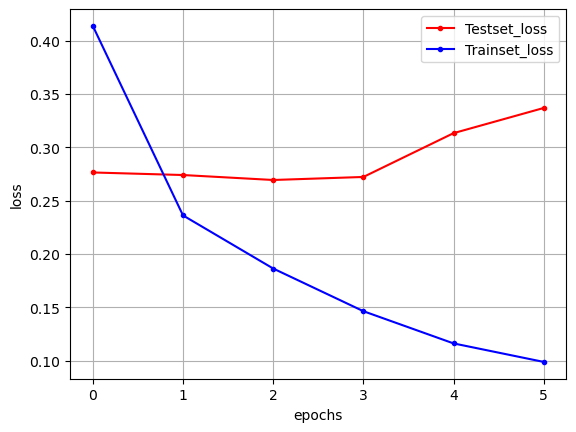

In [8]:
# -----------------------------------------
# 1️⃣ 학습 중 기록된 손실값 가져오기
# -----------------------------------------
# history.history에는
# 모델이 학습하면서 기록한 값들이 들어 있음

# loss     → 학습용 데이터에서 얼마나 틀렸는지
# val_loss → 테스트(검증) 데이터에서 얼마나 틀렸는지
y_vloss=history.history['val_loss']
y_loss=history.history['loss']


# -----------------------------------------
# 2️⃣ x축(학습 횟수) 만들기
# -----------------------------------------
# y_loss의 길이 = 학습한 횟수(epochs)
# 예: 20번 학습 → [0,1,2,...,19]
x_len=np.arange(len(y_loss))


# -----------------------------------------
# 3️⃣ 테스트(검증) 데이터 손실 그래프
# -----------------------------------------
# 빨간색 점과 선으로
# 시험 데이터에서의 오차를 그림
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')

# -----------------------------------------
# 4️⃣ 학습(훈련) 데이터 손실 그래프
# -----------------------------------------
# 파란색 점과 선으로
# 학습 데이터에서의 오차를 그림
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')



# -----------------------------------------
# 5️⃣ 범례 표시
# -----------------------------------------
# 빨간색과 파란색이 무엇인지 설명 표시

plt.legend(loc='upper right')


# -----------------------------------------
# 6️⃣ 격자 표시
# -----------------------------------------
# 그래프를 보기 쉽게 격자 추가
plt.grid()

# -----------------------------------------
# 7️⃣ 축 이름 설정
# -----------------------------------------
# x축 → 학습 횟수
# y축 → 오차(loss)
plt.xlabel('epochs')
plt.ylabel('loss')

# -----------------------------------------
# 8️⃣ 그래프 화면에 출력
# -----------------------------------------
plt.show()

## LSTM과 CNN의 조합을 이용한 영화 리뷰 분류하기


In [ ]:
# =========================================
# 1️⃣ 필요한 라이브러리 불러오기
# =========================================

# 신경망 모델을 순서대로 쌓기 위한 틀
from tensorflow.keras.models import Sequential

# 신경망 층들
# Dense       : 일반 신경망 층
# Dropout     : 과적합 방지 (일부 뉴런 꺼버림)
# Activation  : 활성화 함수 (sigmoid 등)
# Embedding   : 단어 번호 → 의미 벡터로 변환
# LSTM        : 문장 흐름을 기억하는 신경망
# Conv1D      : 문장에서 중요한 단어 패턴을 찾는 CNN
# MaxPooling1D: CNN 결과를 요약해서 줄이는 층
from tensorflow.keras.layers import Dense,Dropout,Activation,Embedding,LSTM, Conv1D, MaxPooling1D

# IMDB 영화 리뷰 데이터셋
from tensorflow.keras.datasets import imdb
# 문장 길이를 맞추는 도구
from tensorflow.keras.preprocessing import sequence

# 학습이 더 이상 좋아지지 않으면 멈추는 기능
from tensorflow.keras.callbacks import EarlyStopping

# 숫자 계산용
import numpy as np
# 그래프 그릴 때 사용
import matplotlib.pyplot as plt


# =========================================
# 2️⃣ IMDB 데이터 불러오기
# =========================================

# num_words=5000 → 가장 많이 쓰인 단어 5000개만 사용
# (나머지 희귀한 단어들은 버림)
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=5000)


# X_train : 영화 리뷰 (단어 번호로 된 문장)
# y_train : 정답 (0 = 나쁜 영화, 1 = 좋은 영화)
# X_test  : 테스트용 리뷰
# y_test  : 테스트용 정답


# =========================================
# 3️⃣ 문장 길이 맞추기
# =========================================

# 모든 리뷰를 길이 500으로 맞춤
# 짧으면 앞에 0 채우고
# 길면 뒤를 잘라냄
X_train=sequence.pad_sequences(X_train,maxlen=500)
X_test=sequence.pad_sequences(X_test,maxlen=500)



# 이제 한 리뷰는:
# [숫자, 숫자, 숫자, ..., 숫자]  ← 500개


# =========================================
# 4️⃣ 모델 만들기
# =========================================

model=Sequential()# 층을 차례대로 쌓는 모델


# Embedding(5000, 100)
# 5000 : 단어 종류 수 (0~4999번)
# 100  : 단어 하나를 100개의 숫자로 표현
# 예) "movie" → [0.2, -0.1, 0.7, ...] (100개)
model.add(Embedding(5000,100))

# =========================================
# 6️⃣ Dropout
# =========================================

# 0.5 → 50%를 랜덤으로 꺼버림
# 과적합(암기) 방지용
model.add(Dropout(0.5))

# =========================================
# 7️⃣ Conv1D (문장 CNN)
# =========================================

# Conv1D(64, 5, padding='valid', activation='relu', strides=1)

# 64 : 필터 개수 (64가지 패턴 찾음)
# 5  : 한 번에 5단어씩 보면서 패턴 찾음
# padding='valid' : 패딩 안 하고 진짜 단어만 사용
# activation='relu' : 음수 제거
# strides=1 : 한 칸씩 이동하면서 스캔
model.add(Conv1D(64,5,padding='valid',activation='relu',strides=1))

# =========================================
# 8️⃣ MaxPooling
# =========================================

# pool_size=4 → 4칸 중 가장 큰 값만 남김
# 문장 길이를 1/4로 줄임
# 중요한 특징만 남김
model.add(MaxPooling1D(pool_size=4))

# =========================================
# 9️⃣ LSTM
# =========================================

# LSTM(55)
# 55 → 기억 칸(뇌 용량)
# CNN이 뽑은 단어 패턴 흐름을 이해함
model.add(LSTM(55))

# =========================================
# 🔟 출력층
# =========================================

# Dense(1) → 하나의 값 출력
# sigmoid → 0~1 사이 확률로 변환
# 0 = 나쁜 영화
# 1 = 좋은 영화
model.add(Dense(1))
model.add(Activation('sigmoid'))

# =========================================
# 11️⃣ 모델 구조 계산용 build
# =========================================

# 원래 한 문장은 500개 단어이므로
# input_shape는 (None, 500)이 맞음
# (None = 배치 크기)
model.build(input_shape=(None,100))

# =========================================
# 12️⃣ 모델 구조 출력
# =========================================
model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 55)             │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,520 (2.13 MB)

 Trainable params: 558,520 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# 1️⃣ 모델 학습 방법 설정
# ============================================
model.compile(
        
    # loss → "얼마나 틀렸는지"를 계산하는 공식
    # binary_crossentropy →
    #    정답이 0 또는 1인 문제 (이진 분류)에 사용
    #    예) 영화가 나쁜지(0) 좋은지(1)
    loss='binary_crossentropy',

    # optimizer → 어떻게 틀린 부분을 고칠지
    # adam →
    #    학습 속도를 자동으로 조절해 주는
    #    가장 많이 쓰이는 똑똑한 최적화 방법
    optimizer='adam',

    # metrics → 학습 중 출력할 성적
    # accuracy →
    #    전체 중 몇 %를 맞췄는지
    metrics=['accuracy'])


# ============================================
# 2️⃣ EarlyStopping 설정
# ============================================
early_stopping_callback=EarlyStopping(
    # monitor → 무엇을 감시할 것인가?
    # val_loss →
    #    중간 시험(검증 데이터)의 오답 정도
    monitor='val_loss',

    # patience →
    #    성능이 좋아지지 않아도
    #    몇 번까지 기다릴지
    # 3 → 3번 연속 좋아지지 않으면 학습 중단
    patience=3)


# ============================================
# 3️⃣ 모델 학습 시작
# ============================================
history=model.fit( # X_train → 학습용 영화 리뷰 (입력)
                   # y_train → 학습용 정답 (0=나쁜영화, 1=좋은영화)
                  X_train,
                  y_train,
                # batch_size=40 →
                #    한 번에 40개 리뷰씩 묶어서 학습
                #    너무 작으면 느리고
                #    너무 크면 부정확해질 수 있음
                  batch_size=40,

                # epochs=100 →
                #    전체 데이터를 최대 100번 반복 학습
                #    EarlyStopping이 있으면
                #    100번 전에 멈출 수도 있음
                  epochs=100,
                # validation_split=0.25 →
                #    학습 데이터 중 25%를
                #    중간 시험용(검증용)으로 사용
                #    75%는 공부, 25%는 시험
                  validation_split=0.25,
                # callbacks →
                #    학습 중 특별한 규칙 적용
                #    여기서는 EarlyStopping 사용
                  callbacks=[early_stopping_callback])


# ============================================
# 4️⃣ 최종 테스트 정확도 출력
# ============================================

# model.evaluate()는
# [loss, accuracy] 형태로 결과를 줌
# [1] → accuracy(정확도)
print('\n Test Accuracy: %.4f' % (model.evaluate(X_test,y_test)[1]))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.7954 - loss: 0.4139 - val_accuracy: 0.8850 - val_loss: 0.2765
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9062 - loss: 0.2362 - val_accuracy: 0.8896 - val_loss: 0.2741
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9296 - loss: 0.1864 - val_accuracy: 0.8890 - val_loss: 0.2695
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9482 - loss: 0.1464 - val_accuracy: 0.8906 - val_loss: 0.2723
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9603 - loss: 0.1162 - val_accuracy: 0.8878 - val_loss: 0.3134
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9666 - loss: 0.0988 - val_accuracy: 0.8877 - val_loss: 0.3370
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8808 - loss: 0.3597

 Test Accuracy: 0.8808


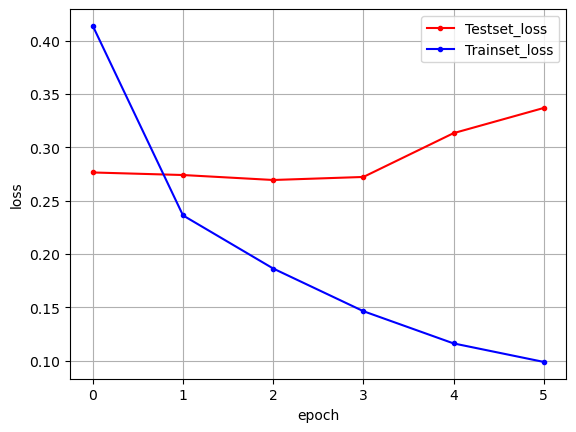

In [ ]:
# model.fit()을 실행하면 history라는 객체가 만들어지고
# 그 안에는 매 epoch마다의 학습 기록이 들어 있음

# ----------------------------------------
# 1️⃣ 검증(테스트용) 오차 가져오기
# ----------------------------------------
# 'val_loss' → 검증 데이터(시험용)에서의 오차
# 즉, 매 epoch마다 시험 성적이 얼마나 틀렸는지를 저장한 리스트
y_vloss=history.history['val_loss']

# ----------------------------------------
# 2️⃣ 훈련(학습용) 오차 가져오기
# ----------------------------------------
# 'loss' → 학습 데이터에서의 오차
# 즉, 매 epoch마다 공부한 문제에서 얼마나 틀렸는지
y_loss=history.history['loss']


# ----------------------------------------
# 3️⃣ x축(학습 횟수, epoch 번호) 만들기
# ----------------------------------------
# y_loss의 길이 = 학습한 횟수(epoch 수)
# 예) y_loss가 [0.6, 0.5, 0.4] 이면
#     3번 학습한 것이므로
#     x_len = [0, 1, 2]
x_len=np.arange(len(y_loss))

# ----------------------------------------
# 4️⃣ 검증 데이터(Test) 오차 그래프
# ----------------------------------------
plt.plot(x_len, # x축: 학습 횟수(epoch)
         y_vloss, # y축: 검증(시험) 데이터의 오차
         marker='.', # 점 모양으로 표시
         c='red', # 선 색깔: 빨간색
         label='Testset_loss')  # 범례에 표시될 이름


# ----------------------------------------
# 5️⃣ 학습 데이터(Train) 오차 그래프
# ----------------------------------------
plt.plot(x_len,  # x축: 학습 횟수(epoch)
         y_loss,  # y축: 학습 데이터의 오차
         marker='.', # 점 모양으로 표시
         c='blue', # 선 색깔: 파란색
         label='Trainset_loss') # 범례 이름


# ----------------------------------------
# 6️⃣ 범례(색깔 설명) 표시
# ----------------------------------------
# 오른쪽 위에
# 파란색 = Trainset_loss
# 빨간색 = Testset_loss
# 를 표시
plt.legend(loc='upper right')

# ----------------------------------------
# 7️⃣ 그래프에 격자선 표시
# ----------------------------------------
# 눈금을 보기 쉽게 만듦
plt.grid()

# ----------------------------------------
# 8️⃣ x축, y축 이름 붙이기
# ----------------------------------------
plt.xlabel('epoch') # x축: 학습 횟수
plt.ylabel('loss') # y축: 오차(틀린 정도)

# ----------------------------------------
# 9️⃣ 그래프 화면에 출력
# ----------------------------------------
plt.show() 

In [9]:
pip install keras-self-attention

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18918 sha256=624a031c86560e00bee732d685bcc105249341d2057259bc0c05a36929cf3cc2
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\bf\1e\40\104c86342a1efceff40b2ef52bf48a0de4f23091abe2ae2ac9
Successfully built keras-self-attention
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'keras-self-attention' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'keras-self-attention'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Embedding,LSTM,Conv1D,MaxPooling1D,Flatten
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model
from keras_self_attention import SeqSelfAttention
import numpy as np
import matplotlib.pyplot as plt

import keras

(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=5000)

X_train=sequence.pad_sequences(X_train,maxlen=500)
X_test=sequence.pad_sequences(X_test,maxlen=500)


model=Sequential()
model.add(Embedding(5000,500))
model.add(Dropout(0.5))
model.add(LSTM(64,return_sequences=True))
model.add(SeqSelfAttention(attention_activation='sigmoid'))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

early_stopping_callback=EarlyStopping(monitor='val_loss',patience=3)

history=model.fit(X_train,
                  y_train,
                  batch_size=40,
                  epochs=100,
                  validation_data=(X_test,y_test),
                  callbacks=[early_stopping_callback])

print("\n Test Accuracy :%.4f" % (model.evaluate(X_test,y_test)[1]))

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 643s 1s/step - accuracy: 0.8253 - loss: 0.3614 - val_accuracy: 0.8956 - val_loss: 0.2538
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 615s 984ms/step - accuracy: 0.9222 - loss: 0.2028 - val_accuracy: 0.8959 - val_loss: 0.2563
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 602s 964ms/step - accuracy: 0.9431 - loss: 0.1523 - val_accuracy: 0.8885 - val_loss: 0.2957
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 530s 847ms/step - accuracy: 0.9603 - loss: 0.1115 - val_accuracy: 0.8814 - val_loss: 0.3139
782/782 ━━━━━━━━━━━━━━━━━━━━ 236s 301ms/step - accuracy: 0.8814 - loss: 0.3139

 Test Accuracy :0.8814


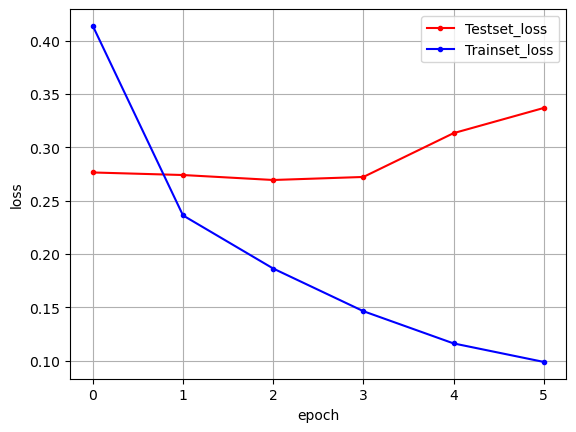

In [10]:
y_vloss=history.history['val_loss']
y_loss=history.history['loss']

x_len=np.arange(len(y_loss))
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')
plt.plot(x_len,y_loss,marker='.',c='blue',label='Trainset_loss')

plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()